<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Web scraping Falcon 9 and Falcon Heavy Launches Records from Wikipedia


Estimated time needed: **40** minutes


In this lab, you will be performing web scraping to collect Falcon 9 historical launch records from a Wikipedia page titled `List of Falcon 9 and Falcon Heavy launches`

https://en.wikipedia.org/wiki/List_of_Falcon_9_and_Falcon_Heavy_launches


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_1_L2/images/Falcon9_rocket_family.svg)


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


More specifically, the launch records are stored in a HTML table shown below:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_1_L2/images/falcon9-launches-wiki.png)


  ## Objectives
Web scrap Falcon 9 launch records with `BeautifulSoup`:
- Extract a Falcon 9 launch records HTML table from Wikipedia
- Parse the table and convert it into a Pandas data frame


First let's import required packages for this lab


In [1]:
!pip3 install beautifulsoup4
# !pip3 install requests

In [2]:
import sys

import requests
from bs4 import BeautifulSoup
import re
import unicodedata
import pandas as pd

and we will provide some helper functions for you to process web scraped HTML table


In [21]:
def date_time(table_cells):
    """
    This function returns the data and time from the HTML  table cell
    Input: the  element of a table data cell extracts extra row
    """
    return [data_time.strip() for data_time in list(table_cells.strings)][0:2]

def booster_version(table_cells):
    """
    This function returns the booster version from the HTML  table cell
    Input: the  element of a table data cell extracts extra row
    """
    out=''.join([booster_version for i,booster_version in enumerate( table_cells.strings) if i%2==0][0:-1])
    return out

def landing_status(table_cells):
    """
    This function returns the landing status from the HTML table cell
    Input: the  element of a table data cell extracts extra row
    """
    out=[i for i in table_cells.strings][0]
    return out


def get_mass(table_cells):
    mass=unicodedata.normalize("NFKD", table_cells.text).strip()
    if mass:
        kg_index = mass.find("kg")
        if kg_index != -1:
            # If 'kg' is found, extract the part up to and including 'kg'
            new_mass=mass[0:kg_index+2]
        else:
            # If 'kg' is not found, clean the string by removing commas
            # This prepares it for pd.to_numeric later, which will handle non-numeric values with errors='coerce'
            new_mass = mass.replace(',', '')
    else:
        new_mass = '0' # Return '0' for empty masses to ensure it's a numeric-like string
    return new_mass


def extract_column_from_header(row):
    """
    This function returns the landing status from the HTML table cell
    Input: the  element of a table data cell extracts extra row
    """
    if (row.br):
        row.br.extract()
    if row.a:
        row.a.extract()
    if row.sup:
        row.sup.extract()

    colunm_name = ' '.join(row.contents)

    # Filter the digit and empty names
    if not(colunm_name.strip().isdigit()):
        colunm_name = colunm_name.strip()
        return colunm_name

To keep the lab tasks consistent, you will be asked to scrape the data from a snapshot of the  `List of Falcon 9 and Falcon Heavy launches` Wikipage updated on
`9th June 2021`


In [5]:
static_url = "https://en.wikipedia.org/w/index.php?title=List_of_Falcon_9_and_Falcon_Heavy_launches&oldid=1027686922"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/91.0.4472.124 Safari/537.36"
}

Next, request the HTML page from the above URL and get a `response` object


### TASK 1: Request the Falcon9 Launch Wiki page from its URL


First, let's perform an HTTP GET method to request the Falcon9 Launch HTML page, as an HTTP response.


In [6]:
# use requests.get() method with the provided static_url and headers
# assign the response to a object
page = requests.get(static_url, headers=headers)

Create a `BeautifulSoup` object from the HTML `response`


In [7]:
from os import setgroups
# Use BeautifulSoup() to create a BeautifulSoup object from a response text content
soup = BeautifulSoup(page.content, 'html.parser')

Print the page title to verify if the `BeautifulSoup` object was created properly


In [8]:
# Use soup.title attribute
print(soup.title)

<title>List of Falcon 9 and Falcon Heavy launches - Wikipedia</title>


### TASK 2: Extract all column/variable names from the HTML table header


Next, we want to collect all relevant column names from the HTML table header


Let's try to find all tables on the wiki page first. If you need to refresh your memory about `BeautifulSoup`, please check the external reference link towards the end of this lab


In [9]:
# Use the find_all function in the BeautifulSoup object, with element type `table`
# Assign the result to a list called `html_tables`
html_tables = soup.find_all('table')

Starting from the third table is our target table contains the actual launch records.


In [10]:
# Let's print the third table and check its content
first_launch_table = html_tables[2]
print(first_launch_table)

<table class="wikitable plainrowheaders collapsible" style="width: 100%;">
<tbody><tr>
<th scope="col">Flight No.
</th>
<th scope="col">Date and<br/>time (<a href="/wiki/Coordinated_Universal_Time" title="Coordinated Universal Time">UTC</a>)
</th>
<th scope="col"><a href="/wiki/List_of_Falcon_9_first-stage_boosters" title="List of Falcon 9 first-stage boosters">Version,<br/>Booster</a> <sup class="reference" id="cite_ref-booster_11-0"><a href="#cite_note-booster-11"><span class="cite-bracket">[</span>b<span class="cite-bracket">]</span></a></sup>
</th>
<th scope="col">Launch site
</th>
<th scope="col">Payload<sup class="reference" id="cite_ref-Dragon_12-0"><a href="#cite_note-Dragon-12"><span class="cite-bracket">[</span>c<span class="cite-bracket">]</span></a></sup>
</th>
<th scope="col">Payload mass
</th>
<th scope="col">Orbit
</th>
<th scope="col">Customer
</th>
<th scope="col">Launch<br/>outcome
</th>
<th scope="col"><a href="/wiki/Falcon_9_first-stage_landing_tests" title="Falcon 

You should able to see the columns names embedded in the table header elements `<th>` as follows:


```
<tr>
<th scope="col">Flight No.
</th>
<th scope="col">Date and<br/>time (<a href="/wiki/Coordinated_Universal_Time" title="Coordinated Universal Time">UTC</a>)
</th>
<th scope="col"><a href="/wiki/List_of_Falcon_9_first-stage_boosters" title="List of Falcon 9 first-stage boosters">Version,<br/>Booster</a> <sup class="reference" id="cite_ref-booster_11-0"><a href="#cite_note-booster-11">[b]</a></sup>
</th>
<th scope="col">Launch site
</th>
<th scope="col">Payload<sup class="reference" id="cite_ref-Dragon_12-0"><a href="#cite_note-Dragon-12">[c]</a></sup>
</th>
<th scope="col">Payload mass
</th>
<th scope="col">Orbit
</th>
<th scope="col">Customer
</th>
<th scope="col">Launch<br/>outcome
</th>
<th scope="col"><a href="/wiki/Falcon_9_first-stage_landing_tests" title="Falcon 9 first-stage landing tests">Booster<br/>landing</a>
</th></tr>
```


Next, we just need to iterate through the `<th>` elements and apply the provided `extract_column_from_header()` to extract column name one by one


In [11]:
column_names = []

# Apply find_all() function with `th` element on first_launch_table
# Iterate each th element and apply the provided extract_column_from_header() to get a column name
# Append the Non-empty column name (`if name is not None and len(name) > 0`) into a list called column_names
find_all_th = first_launch_table.find_all('th')
for th in find_all_th:
    name = extract_column_from_header(th)
    if name is not None and len(name) > 0:
        column_names.append(name)

Check the extracted column names


In [12]:
print(column_names)

['Flight No.', 'Date and time ( )', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome']


## TASK 3: Create a data frame by parsing the launch HTML tables


We will create an empty dictionary with keys from the extracted column names in the previous task. Later, this dictionary will be converted into a Pandas dataframe


In [14]:
launch_dict= dict.fromkeys(column_names)

# Remove an irrelvant column
del launch_dict['Date and time ( )']

# Let's initial the launch_dict with each value to be an empty list
launch_dict['Flight No.'] = []
launch_dict['Launch site'] = []
launch_dict['Payload'] = []
launch_dict['Payload mass'] = []
launch_dict['Orbit'] = []
launch_dict['Customer'] = []
launch_dict['Launch outcome'] = []
# Added some new columns
launch_dict['Version Booster']=[]
launch_dict['Booster landing']=[]
launch_dict['Date']=[]
launch_dict['Time']=[]

Next, we just need to fill up the `launch_dict` with launch records extracted from table rows.


Usually, HTML tables in Wiki pages are likely to contain unexpected annotations and other types of noises, such as reference links `B0004.1[8]`, missing values `N/A [e]`, inconsistent formatting, etc.


To simplify the parsing process, we have provided an incomplete code snippet below to help you to fill up the `launch_dict`. Please complete the following code snippet with TODOs or you can choose to write your own logic to parse all launch tables:


In [16]:
extracted_row = 0
#Extract each table
for table_number,table in enumerate(soup.find_all('table',"wikitable plainrowheaders collapsible")):
   # get table row
    for rows in table.find_all("tr"):
        #check to see if first table heading is as number corresponding to launch a number
        if rows.th:
            if rows.th.string:
                flight_number=rows.th.string.strip()
                flag=flight_number.isdigit()
        else:
            flag=False
        #get table element
        row=rows.find_all('td')
        #if it is number save cells in a dictonary
        if flag:
            extracted_row += 1
            # Flight Number value
            # TODO: Append the flight_number into launch_dict with key `Flight No.`
            launch_dict['Flight No.'].append(flight_number)
            #print(flight_number)
            datatimelist=date_time(row[0])

            # Date value
            # TODO: Append the date into launch_dict with key `Date`
            date = datatimelist[0].strip(',')
            launch_dict['Date'].append(date)
            #print(date)

            # Time value
            # TODO: Append the time into launch_dict with key `Time`
            time = datatimelist[1]
            launch_dict['Time'].append(time)
            #print(time)

            # Booster version
            # TODO: Append the bv into launch_dict with key `Version Booster`
            bv=booster_version(row[1])
            if not(bv) and row[1].a: # Added check for row[1].a
                bv=row[1].a.string
            elif not(bv): # If bv is still empty and no 'a' tag, set to empty string
                bv = ''
            launch_dict['Version Booster'].append(bv)
            #print(bv)

            # Launch Site
            # TODO: Append the bv into launch_dict with key `Launch Site`
            launch_site = '' # Initialize with an empty string
            if row[2].a: # Check if the 'a' tag exists
                launch_site = row[2].a.string
            launch_dict['Launch site'].append(launch_site)
            #print(launch_site)

            # Payload
            # TODO: Append the payload into launch_dict with key `Payload`
            payload = '' # Initialize with an empty string
            if row[3].a: # Check if the 'a' tag exists
                payload = row[3].a.string
            launch_dict['Payload'].append(payload)
            #print(payload)

            # Payload Mass
            # TODO: Append the payload_mass into launch_dict with key `Payload mass`
            payload_mass = get_mass(row[4])
            launch_dict['Payload mass'].append(payload_mass)
            #print(payload_mass) # Corrected print statement

            # Orbit
            # TODO: Append the orbit into launch_dict with key `Orbit`
            orbit = '' # Initialize with an empty string
            if row[5].a: # Check if the 'a' tag exists
                orbit = row[5].a.string
            launch_dict['Orbit'].append(orbit)
            #print(orbit)

            # Customer
            # TODO: Append the customer into launch_dict with key `Customer`
            customer = '' # Initialize with an empty string
            if row[6].a: # Check if the 'a' tag exists
                customer = row[6].a.string
            launch_dict['Customer'].append(customer)
            #print(customer)

            # Launch outcome
            # TODO: Append the launch_outcome into launch_dict with key `Launch outcome`
            launch_outcome = list(row[7].strings)[0]
            launch_dict['Launch outcome'].append(launch_outcome)
            #print(launch_outcome)

            # Booster landing
            # TODO: Append the launch_outcome into launch_dict with key `Booster landing`
            booster_landing = landing_status(row[8])
            launch_dict['Booster landing'].append(booster_landing)
            #print(booster_landing)

After you have fill in the parsed launch record values into `launch_dict`, you can create a dataframe from it.


In [19]:
df= pd.DataFrame({ key:pd.Series(value) for key, value in launch_dict.items() })

### Визуализация зависимости Payload mass от Orbit

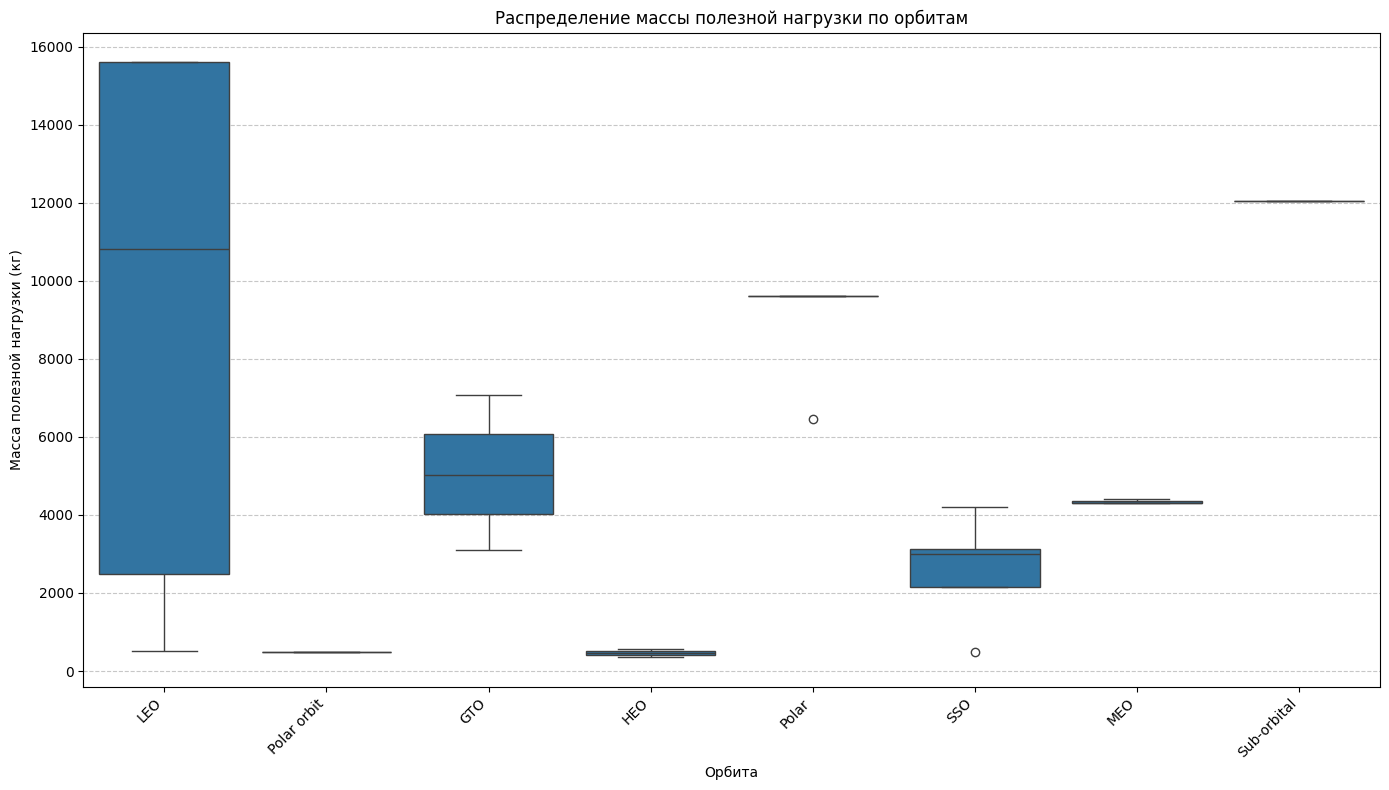

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for NaN

# Clean 'Payload mass' column
# Convert to string first to handle mixed types gracefully
df['Payload mass'] = df['Payload mass'].astype(str).str.replace(' kg', '', regex=False).str.replace(',', '', regex=False)
# Convert to numeric, coercing errors to NaN
df['Payload mass'] = pd.to_numeric(df['Payload mass'], errors='coerce')

# Create a box plot
plt.figure(figsize=(14, 8))
sns.boxplot(x='Orbit', y='Payload mass', data=df)
plt.title('Распределение массы полезной нагрузки по орбитам')
plt.xlabel('Орбита')
plt.ylabel('Масса полезной нагрузки (кг)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [23]:
df.to_csv('spacex_web_scraped.csv', index=False)

### Расчет средней массы полезной нагрузки для каждой орбиты

In [24]:
average_payload_mass_per_orbit = df.groupby('Orbit')['Payload mass'].mean().reset_index()

print("Средняя масса полезной нагрузки для каждой орбиты:")
display(average_payload_mass_per_orbit)

Средняя масса полезной нагрузки для каждой орбиты:


,Orbit,Payload mass
0,GTO,5063.687500
1,HEO,466.000000
2,LEO,9018.931034
3,MEO,4340.666667
4,Polar,9151.428571
5,Polar orbit,500.000000
6,SSO,2591.000000
7,Sub-orbital,12050.000000


### Гистограмма распределения количества запусков по орбитам

/tmp/ipykernel_8976/543220086.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Orbit', y='Launch Count', data=orbit_counts, palette='viridis')


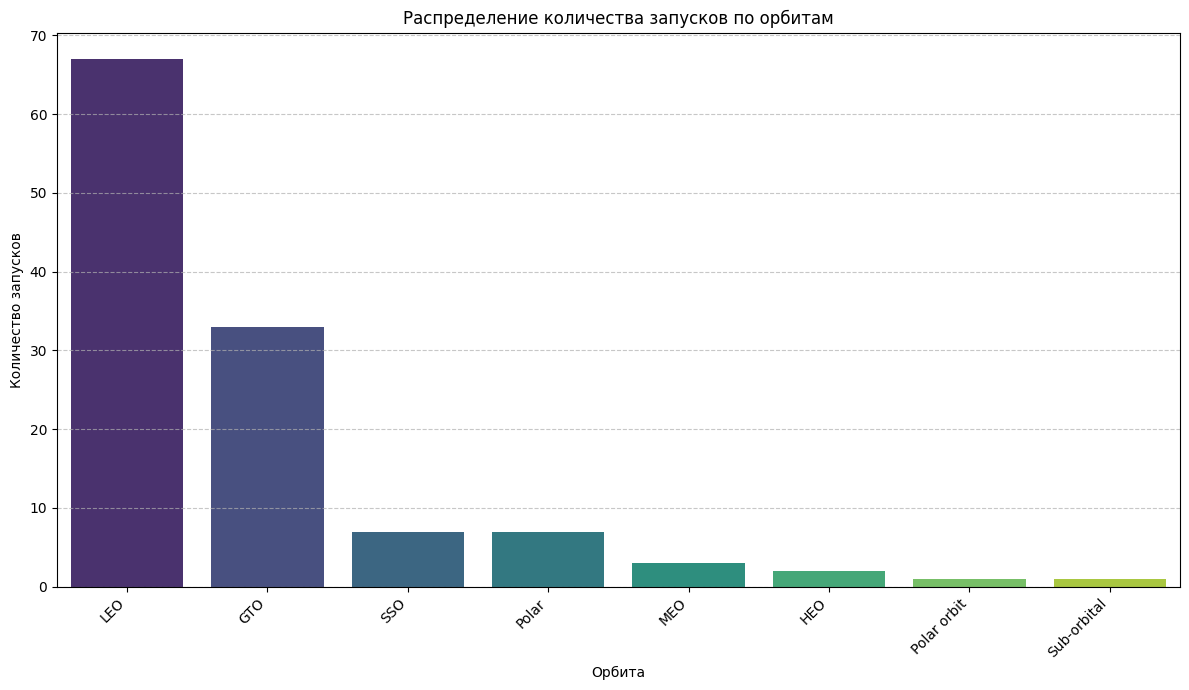

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of launches for each orbit
orbit_counts = df['Orbit'].value_counts().reset_index()
orbit_counts.columns = ['Orbit', 'Launch Count']

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Orbit', y='Launch Count', data=orbit_counts, palette='viridis')
plt.title('Распределение количества запусков по орбитам')
plt.xlabel('Орбита')
plt.ylabel('Количество запусков')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Гистограмма распределения количества запусков по стартовым площадкам

/tmp/ipykernel_8976/895521395.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Launch Site', y='Launch Count', data=launch_site_counts, palette='viridis')


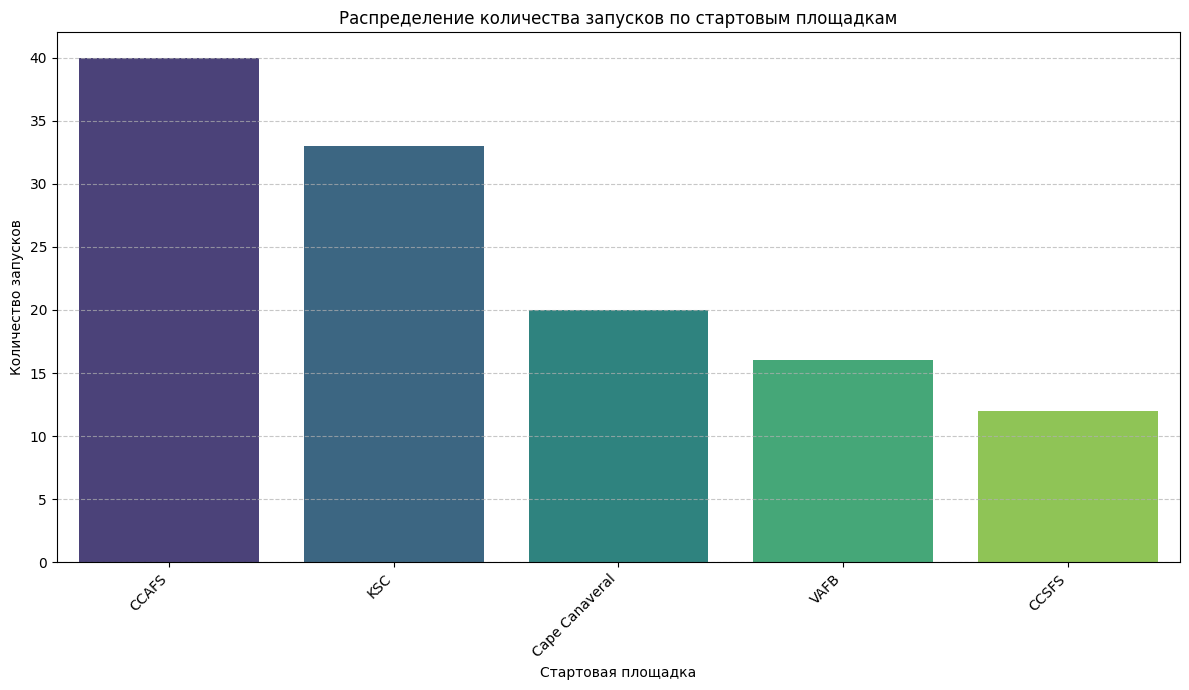

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of launches for each launch site
launch_site_counts = df['Launch site'].value_counts().reset_index()
launch_site_counts.columns = ['Launch Site', 'Launch Count']

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Launch Site', y='Launch Count', data=launch_site_counts, palette='viridis')
plt.title('Распределение количества запусков по стартовым площадкам')
plt.xlabel('Стартовая площадка')
plt.ylabel('Количество запусков')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### График зависимости успеха миссии от стартовой площадки

/tmp/ipykernel_8976/2302661578.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Launch Site', y='Mission Success Rate', data=mission_success_by_site, palette='coolwarm')


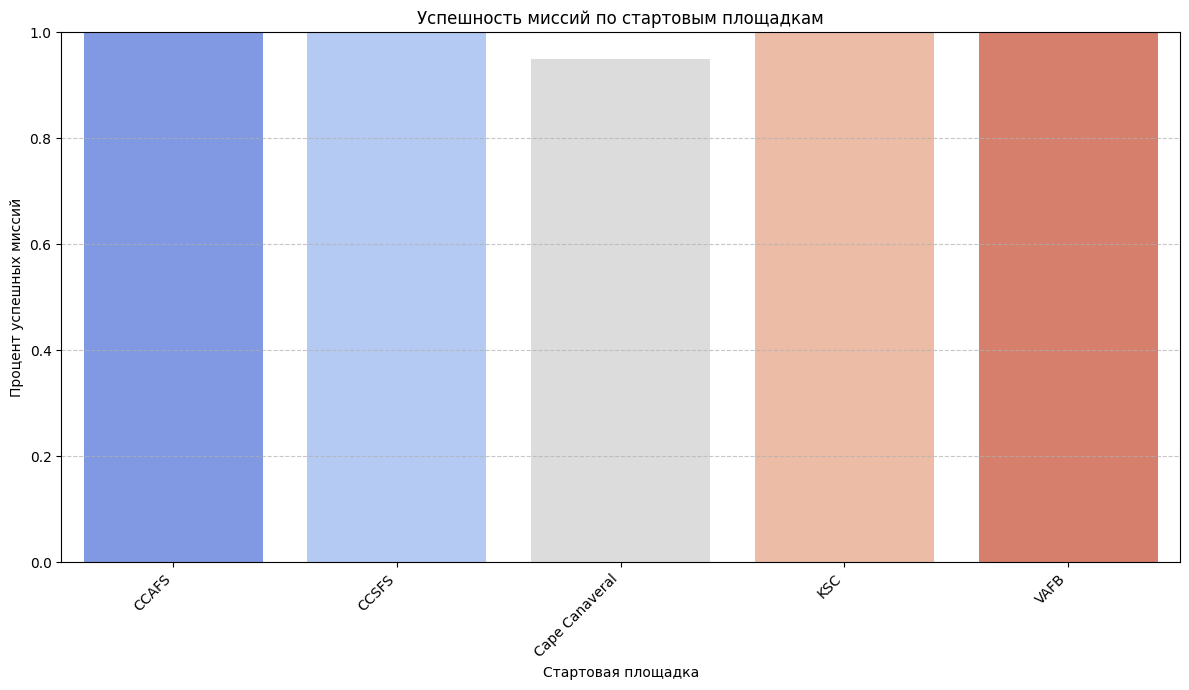

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Launch outcome' to a numerical success indicator
df['Mission Success'] = df['Launch outcome'].apply(lambda x: 1 if 'Success' in x else 0)

# Calculate the average mission success rate per launch site
mission_success_by_site = df.groupby('Launch site')['Mission Success'].mean().reset_index()
mission_success_by_site.columns = ['Launch Site', 'Mission Success Rate']

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Launch Site', y='Mission Success Rate', data=mission_success_by_site, palette='coolwarm')
plt.title('Успешность миссий по стартовым площадкам')
plt.xlabel('Стартовая площадка')
plt.ylabel('Процент успешных миссий')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Ensure y-axis is between 0 and 1 for percentage
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### График корреляции между массой полезной нагрузки и успехом миссии

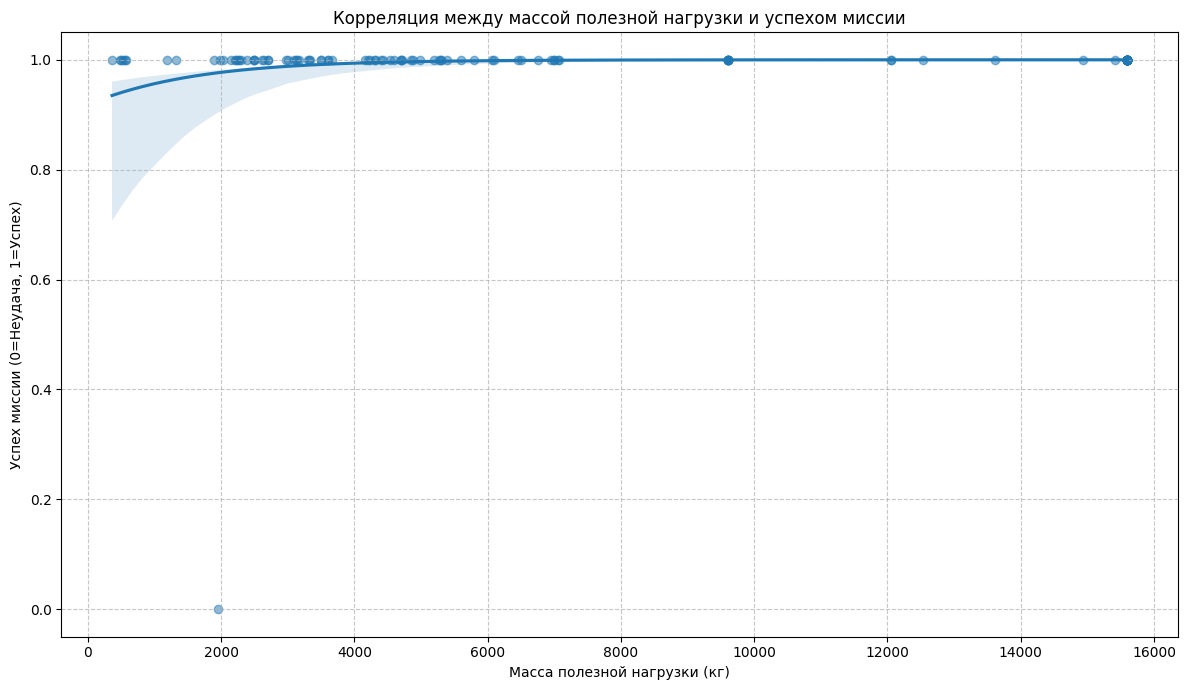

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot with a regression line
plt.figure(figsize=(12, 7))
sns.regplot(x='Payload mass', y='Mission Success', data=df, logistic=True, scatter_kws={'alpha':0.5})
plt.title('Корреляция между массой полезной нагрузки и успехом миссии')
plt.xlabel('Масса полезной нагрузки (кг)')
plt.ylabel('Успех миссии (0=Неудача, 1=Успех)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<code>df.to_csv('spacex_web_scraped.csv', index=False)</code>


## Authors


<a href="https://www.linkedin.com/in/yan-luo-96288783/">Yan Luo</a>


<a href="https://www.linkedin.com/in/nayefaboutayoun/">Nayef Abou Tayoun</a>


<!--
## Change Log
-->


<!--
| Date (YYYY-MM-DD) | Version | Changed By | Change Description      |
| ----------------- | ------- | ---------- | ----------------------- |
| 2021-06-09        | 1.0     | Yan Luo    | Tasks updates           |
| 2020-11-10        | 1.0     | Nayef      | Created the initial version |
-->


Copyright © 2021 IBM Corporation. All rights reserved.
